# Predicting sentiment from product reviews using logistic regression


The goal of this notebook is to implement logistic regression and feature engineering for predicting product review sentiment using the Amazon Reviews dataset.

* Convert text data to numerical features using Bag-of-Word model and Term-Frequency Inverse Document Frequency (TF_IDF)
* Train a logistic regression model to predict the sentiment of product reviews.
* Inspect the coefficients of the logistic regression model and interpret their meanings.
* Make a prediction (both class and probability) of sentiment for a new product review.
* Evaluate LG models using accuracy, precision, and recall.

Let's get started!

# Data preparation

We will use a dataset consisting of Amazon.com product reviews.

In [391]:
import pandas as pd
products = pd.read_csv('../datasets/Amazon Product Reviews I.csv')

In [392]:
# Observe the dataset features
print(products.head())

                     id       asins   brand                  categories  \
0  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
1  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
2  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
3  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   
4  AVpe7AsMilAPnD_xQ78G  B00QJDU3KY  Amazon  Amazon Devices,mazon.co.uk   

  colors             dateAdded           dateUpdated  \
0    NaN  2016-03-08T20:21:53Z  2017-07-18T23:52:58Z   
1    NaN  2016-03-08T20:21:53Z  2017-07-18T23:52:58Z   
2    NaN  2016-03-08T20:21:53Z  2017-07-18T23:52:58Z   
3    NaN  2016-03-08T20:21:53Z  2017-07-18T23:52:58Z   
4    NaN  2016-03-08T20:21:53Z  2017-07-18T23:52:58Z   

                  dimension  ean                         keys  ...  \
0  169 mm x 117 mm x 9.1 mm  NaN  kindlepaperwhite/b00qjdu3ky  ...   
1  169 mm x 117 mm x 9.1 mm  NaN  kindlepaperwhite/b00qjdu3ky  ...   
2 

In [393]:
import numpy as np
name=np.unique(products['name'])
print(name[0:10])

['Alexa Voice Remote for Amazon Echo and Echo Dot'
 'Alexa Voice Remote for Amazon Fire TV and Fire TV Stick'
 'All-New Amazon Fire 7 Tablet Case (7th Generation'
 'All-New Amazon Fire HD 8 Tablet Case (7th Generation'
 'All-New Amazon Fire TV Game Controller'
 'All-New Amazon Kid-Proof Case for Amazon Fire 7 Tablet (7th Generation'
 'All-New Amazon Kid-Proof Case for Amazon Fire HD 8 Tablet (7th Generation'
 'All-New Fire 7 Kids Edition Tablet' 'All-New Fire 7 Tablet with Alexa'
 'All-New Fire HD 8 Kids Edition Tablet']


Now, let us simplify feature names and drop irrelevant features.

In [394]:
# Simplify relevant columns names
if('reviews.rating' in products.columns):
    products['rating']=products['reviews.rating']
    products.drop(['reviews.rating'],axis=1, inplace=True)

if('reviews.text' in products.columns):
    products['reviews']=products['reviews.text']
    products.drop(['reviews.text'],axis=1, inplace=True)
    
if('reviews.title' in products.columns):
    products['title']=products['reviews.title']
    products.drop(['reviews.title'],axis=1, inplace=True)

In [395]:
# Drop irrelevant columns
relevant_cols=['reviews','rating','title']
products = products.loc[:, relevant_cols]

In [396]:
print(products.head())

                                             reviews  rating  \
0  I initially had trouble deciding between the p...     5.0   
1  Allow me to preface this with a little history...     5.0   
2  I am enjoying it so far. Great for reading. Ha...     4.0   
3  I bought one of the first Paperwhites and have...     5.0   
4  I have to say upfront - I don't like coroporat...     5.0   

                                        title  
0              Paperwhite voyage, no regrets!  
1           One Simply Could Not Ask For More  
2  Great for those that just want an e-reader  
3                    Love / Hate relationship  
4                                   I LOVE IT  


# Drop Nans

In [397]:
products.dropna(subset=['rating', 'reviews','title'], inplace=True)
products.reset_index(drop=True, inplace=True)

Let us explore a specific example of a Amazon product.

In [398]:
print(products['reviews'][269])

I can read a lot longer without pain in my hands since the cover holds it for me. Very nice shade of blue.


# Clean text data

Now, we will perform 2 simple data transformations:

1. Remove punctuation using [Python's built-in](https://docs.python.org/2/library/string.html) string functionality.
2. Transform the reviews into word-counts or tf-idf features.

**Aside**. In this notebook, we remove all punctuations for the sake of simplicity. A smarter approach to punctuations would preserve phrases such as "I'd", "would've", "hadn't" and so forth. See [this page](https://neptune.ai/blog/tokenization-in-nlp) for an example of smart handling of punctuations.

In [399]:
import string 
def remove_punctuation(text):
    try: # python 2.x
        text = text.translate(None, string.punctuation) 
    except: # python 3.x
        translator = text.maketrans('', '', string.punctuation)
        text = text.translate(translator)
    return text

In [400]:
products['reviews'] = products['reviews'].apply(remove_punctuation)
print(products['reviews'])

0       I initially had trouble deciding between the p...
1       Allow me to preface this with a little history...
2       I am enjoying it so far Great for reading Had ...
3       I bought one of the first Paperwhites and have...
4       I have to say upfront  I dont like coroporate ...
                              ...                        
1172    This is not the same remote that I got for my ...
1173    I have had to change the batteries in this rem...
1174    Remote did not activate nor did it connect to ...
1175    It does the job but is super over priced I fee...
1176    I ordered this item to replace the one that no...
Name: reviews, Length: 1177, dtype: object


Use stop words to clean text data

In [401]:
stop_words_list = open("../datasets/stopwords.csv","r")
stop_words_list = stop_words_list.readlines()
stop_words=[]
for word in stop_words_list:
    stop_words.append(word.split('\n')[0])
print(stop_words[:10])

['x', 'y', 'your', 'yours', 'yourself', 'yourselves', 'you', 'yond', 'yonder', 'yon']


## Build the word count vector for each review

In [402]:
# Word count parameters
analyzer='word'                # ‘word’, ‘char’, ‘char_wb’
ngram_range=(1, 1)             # unigram - (1,1), unigram & bigram - (1,2), bigram - (2,2)
stop_words=stop_words          # stop_words or 'english'

In [403]:
# Word Importance: Frequency counts
from sklearn.feature_extraction.text import CountVectorizer

# Use the CountVectorizer() from sklearn.feature_extraction.text to create a count vectorizer class object. 
count_vect = CountVectorizer(analyzer=analyzer, ngram_range=ngram_range, stop_words=stop_words)
X_train_counts = count_vect.fit_transform(products['reviews'])

/Users/angeliquetaylor/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['come', 'vis', 'viser', 'visest'] not in stop_words.
  warnings.warn(


Use the count vectorizer transform() function to transform the features in df to create frequency counts for words.

In [404]:
wc_feature_names = np.array(count_vect.get_feature_names_out())
print('wc_feature_names: {}'.format(wc_feature_names))

wc_feature_names: ['029' '034' '035' ... 'zink' 'zippy' 'zoom']


Convert the frequency counts to an array using the toarray() function and convert the array to a pandas dataframe.

In [405]:
word_count_df = pd.DataFrame(X_train_counts.toarray())

Add a prefix to the column names in the data frame created in Step 3 using add_prefix() pandas function with ‘word_count_’ as the prefix.

In [406]:
word_count_df = word_count_df.add_prefix('word_count_')

Append word_count features to the dataframe.

In [407]:
products = pd.concat([products, word_count_df], axis=1)

Confirm the length of the word_count dataframe.

In [408]:
print('Feature {} has been word count encoded from {} reviews.'.format('reviews', len(word_count_df)))

Feature reviews has been word count encoded from 1177 reviews.


# Build the TF-IDF word vector for each review

In [409]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Use the TfidfVectorizer() from sklearn.feature_extraction.text to create a TF-IDF transformer class object. 
tfidf = TfidfVectorizer(analyzer=analyzer, ngram_range=ngram_range, stop_words=stop_words)

# Transform the frequency counts (from Step 2) into TF-IDF features using the TfidfTransformer object.
X_train_tfidf = tfidf.fit_transform(products['reviews'])

# Create a pandas dataframe for the TF-IDF features which takes the TF-IDF features array as input so convert the TF-IDF features to an array using the toarray() function.
tfidf_df = pd.DataFrame(X_train_tfidf.toarray())

# Add a prefix to the column names in the data frame created in Step 3 using add_prefix() pandas function with ‘tf_idf_word_count_’ as the prefix.
tfidf_df = word_count_df.add_prefix('tfidf_word_count_')

# Get feature names
tfidf_feature_names = np.array(tfidf.get_feature_names_out())
print('tfidf_feature_names: {}'.format(tfidf_feature_names))

tfidf_feature_names: ['029' '034' '035' ... 'zink' 'zippy' 'zoom']


/Users/angeliquetaylor/anaconda3/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['come', 'vis', 'viser', 'visest'] not in stop_words.
  warnings.warn(


In [410]:
# Append the TF-IDF dataframe to df using the pd.concat() function.
products = pd.concat([products, tfidf_df], axis=1)
print(products.head())

                                             reviews  rating  \
0  I initially had trouble deciding between the p...     5.0   
1  Allow me to preface this with a little history...     5.0   
2  I am enjoying it so far Great for reading Had ...     4.0   
3  I bought one of the first Paperwhites and have...     5.0   
4  I have to say upfront  I dont like coroporate ...     5.0   

                                        title  word_count_0  word_count_1  \
0              Paperwhite voyage, no regrets!             0             0   
1           One Simply Could Not Ask For More             0             0   
2  Great for those that just want an e-reader             0             0   
3                    Love / Hate relationship             0             0   
4                                   I LOVE IT             0             0   

   word_count_2  word_count_3  word_count_4  word_count_5  word_count_6  ...  \
0             0             0             0             0             0 

## Preprocess sentiment targets

We will **ignore** all reviews with *rating = 3*, since they tend to have a neutral sentiment.

In [411]:
products = products[products['rating'] != 3]
products.reset_index(drop=True, inplace=True)
products.shape

(1053, 12893)

Now, we will assign reviews with a rating of 4 or higher to be *positive* reviews, while the ones with rating of 2 or lower are *negative*. For the sentiment column, we use +1 for the positive class label and -1 for the negative class label.

In [412]:
products['sentiment'] = products['rating'].apply(lambda r: +1 if r > 3 else -1)
products.head()

,reviews,rating,title,word_count_0,word_count_1,word_count_2,word_count_3,word_count_4,word_count_5,word_count_6,...,tfidf_word_count_word_count_6436,tfidf_word_count_word_count_6437,tfidf_word_count_word_count_6438,tfidf_word_count_word_count_6439,tfidf_word_count_word_count_6440,tfidf_word_count_word_count_6441,tfidf_word_count_word_count_6442,tfidf_word_count_word_count_6443,tfidf_word_count_word_count_6444,sentiment
0,I initially had trouble deciding between the p...,5.0,"Paperwhite voyage, no regrets!",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,Allow me to preface this with a little history...,5.0,One Simply Could Not Ask For More,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,I am enjoying it so far Great for reading Had ...,4.0,Great for those that just want an e-reader,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,I bought one of the first Paperwhites and have...,5.0,Love / Hate relationship,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,I have to say upfront I dont like coroporate ...,5.0,I LOVE IT,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Now, we can see that the dataset contains an extra column called **sentiment** which is either positive (+1) or negative (-1).

## Split data into training and test sets

Let's perform a train/test split with 80% of the data in the training set and 20% of the data in the test set. We use `seed=1` so that everyone gets the same result.

In [413]:
# Seperate training and test data
X, y = products.loc[:, ~products.columns.isin(['sentiment'])], products.loc[:, products.columns.isin(['sentiment'])]

In [414]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=1)

Just like in the earlier assignments, we convert Pandas dataframe into a NumPy array. Two arrays are returned: one representing features and another representing class labels. 

In [415]:
print('Training set size: {}'.format(len(X_train)))
print('Test set size: {}'.format(len(X_test)))

Training set size: 842
Test set size: 211


## Building a logistic regression model

Recall from lecture that the link function for logistic regression can be defined as:

$$
P(y_i = +1 | \mathbf{x}_i,\mathbf{w}) = \frac{1}{1 + \exp(-\mathbf{w}^T h(\mathbf{x}_i))},
$$

where the feature vector $h(\mathbf{x}_i)$ is given by the word counts of **important_words** in the review $\mathbf{x}_i$. 


We will now use logistic regression to create a sentiment classifier on the training data. This model will use the column **word_count** as a feature and the column **sentiment** as the target. 

In [416]:
def predict_probability(X, W, b=0):
    '''
    Produces probabilistic estimate for P(y_i = +1 | x_i, w)
        Estimate ranges between 0 and 1.
    Input:
        - X: Input features
        - W: weights/coefficients of logistic regression model
        - b: bias or y-intercept of logistic regression classifier
    Output:
        - y_pred: probability of positive product review
    '''
    # Take dot product of feature_matrix and coefficients  
    score = np.dot(X, W)+b
    
    # Compute P(y_i = +1 | x_i, w) using the link function
    y_pred = 1. / (1.+np.exp(-score))    
    return y_pred

To track the performance of gradient ascent, we provide a function for computing **average log likelihood**. 

$$
\frac{\partial \ell(\mathbf{w})}{\partial \mathbf{w_j}} = \sum_{i=1}^N h_j(x_i)((\mathbf{1}
[y_i=+1]) - P(y=+1|x_i,\mathbf{w}))
$$

### Intuition: What is log-likelihood and why do we need it?

Imagine you're training a model to predict whether a product review is positive or negative. After each round of training, you want to ask: **"Did the model get better or worse?"** Log-likelihood is the number that answers this question.

**Think of it like a confidence score for your model:**
- Your model looks at a review and says "I'm 90% sure this is positive." If the review actually **is** positive, that's a good prediction -- the model gets a high score for that example.
- But if the review is actually **negative**, the model was confidently wrong -- it gets a very low (very negative) score for that example.

The log-likelihood adds up these scores across **all** training examples. A higher (less negative) value means the model is doing a better job overall.

**Why "log"?** Our model outputs probabilities (numbers between 0 and 1). Multiplying thousands of small probabilities together gives a tiny number that computers can't handle well. Taking the logarithm converts these multiplications into additions, which is numerically stable and easier to work with. The log also has a nice property: log(1.0) = 0 (perfect confidence in the right answer), and log(0.0) = -infinity (complete confidence in the wrong answer).

**Why do we track it over training iterations?** Each time we update the weights using gradient ascent, the log-likelihood should increase (or at least not decrease). If you plot it over iterations and see it going up and leveling off, your model is converging -- it's learning! If it's going down or oscillating wildly, something is wrong (often the learning rate is too high).

### Understanding `compute_log_likelihood`

The `compute_log_likelihood` function measures how well the current weights explain the training data. It computes the **average log-likelihood** across all samples, which is the objective that gradient ascent maximizes.

For logistic regression, the log-likelihood of a single sample $i$ is:

$$
\ell_i = \begin{cases} \log P(y=+1 \mid \mathbf{x}_i, \mathbf{w}) = -\log(1 + e^{-\mathbf{w}^T \mathbf{x}_i}) & \text{if } y_i = +1 \\
\log P(y=-1 \mid \mathbf{x}_i, \mathbf{w}) = -\mathbf{w}^T \mathbf{x}_i -\log(1 + e^{-\mathbf{w}^T \mathbf{x}_i}) & \text{if } y_i = -1 \end{cases}
$$

The function combines both cases using an indicator variable $\mathbf{1}[y_i = +1]$ (which is 1 for positive and 0 for negative):

$$
\ell_i = (\mathbf{1}[y_i = +1] - 1) \cdot \text{score}_i - \log(1 + e^{-\text{score}_i})
$$

You can verify this works for both cases:
- **Positive** ($\mathbf{1} = 1$): $(1-1) \cdot s - \log(1+e^{-s}) = -\log(1+e^{-s})$
- **Negative** ($\mathbf{1} = 0$): $(0-1) \cdot s - \log(1+e^{-s}) = -s - \log(1+e^{-s})$

The function also includes an **overflow guard**: when scores are very negative, $e^{-\text{score}}$ can overflow to infinity. In that case, $\log(1 + e^{-s}) \approx -s$, so the function substitutes $-s$ directly.

Finally, the total is averaged over $N$ samples to get the **average** log-likelihood, which we track over training iterations to monitor convergence.

In [417]:
def compute_log_likelihood(X, Y, W, b):
    '''
    Compute the average log-likelihood of logistic regression coefficients
    Input
        - X: subset of features in dataset
        - Y: true sentiment of inputs
        - W: logistic regression weights
    Output
        - lp: log likelihood estimation
    '''
    lp=None
    indicator = (Y==+1)
    scores = np.dot(X, W) + b
    logexp = np.log(1. + np.exp(-scores))
    # Simple check to prevent overflow
    mask = np.isinf(logexp)
    logexp[mask] = -scores[mask]
    lp = np.sum((indicator-1)*scores - logexp)/len(X)
    return lp

In [418]:
# Helper function to update weights in gradient descent 
def update_weights(X, Y, W, b, learning_rate, log_likelihood):      
    '''
    Update weights of logistic regression model using gradient ascent.
    Compute the derivative and update weights.
    Inputs
        - X: Input features
        - Y: list of actual product sentiment classes 
        - W: weights/coefficients of logistic regression model
        - b: bias or y-intercept of logistic regression classifier
        - learning_rate: learning rate
        - log_likelihood: log likelihood of weights
    Output:
        - W: predicted weights
        - b: predicted bias
        - log_likelihood: log likelihood
    '''
    # Number of examples, Number of features         
    num_features, num_examples = X.shape
    # Make a prediction
    y_pred = 1 / (1 + np.exp(-(X.dot(W) + b))) 
    
    dW = X.T.dot(Y-y_pred) / num_features 
    db = np.sum(Y-y_pred) / num_features 

    # update weights and bias
    b = b + learning_rate * db
    W = W + learning_rate * dW

    # Compute log likelihood
    log_likelihood = compute_log_likelihood(X, Y, W, b)

    return W, b, log_likelihood

In [419]:
def predict(X, W, b):
    '''
    Hypothetical function  h(x)
    Input: 
        - X: Input features
        - W: weights/coefficients of logistic regression model
        - b: bias or y-intercept of logistic regression classifier
    Output:
        - Y: list of predicted classes 
    '''
    Z = 1 / (1 + np.exp(- (X.dot(W) + b)))
    Y = [-1 if z <= 0.5 else +1 for z in Z]
    return Y

In [420]:
def fit(X, Y, num_iterations, learning_rate):   
    '''
    Fit features to data using logistic regression 
    Input: 
        - X: Input features
        - Y: list of actual product sentiment classes 
        - num_iterations: # of iterations to update weights using gradient ascent
        - learning_rate: learning rate
    Output:
        - W: predicted weights
        - b: predicted bias
        - likelihood_history: history of log likelihood
    '''
    # no_of_training_examples, no_of_features         
    num_features, num_examples = X.shape    
    
    # weight initialization         
    W = np.zeros(num_examples)
    b = 0
    log_likelihood=0
    likelihood_history=[]
      
    # gradient ascent learning 
    for i in range(num_iterations):          
        W, b, log_likelihood = update_weights(X, Y, W, b, learning_rate, log_likelihood)   
        likelihood_history.append(log_likelihood)
    return W, b, likelihood_history

In [421]:
# Use BoWs or TF-IDF features
feature_encoding = 'word_count_' # BoW: 'word_count_' or TF-IDF: 'tfidf_word_count_'

# Use raw features
X_train_sentiment = X_train.loc[:,X_train.columns.str.startswith(feature_encoding)].to_numpy()    
X_test_sentiment = X_test.loc[:,X_test.columns.str.startswith(feature_encoding)].to_numpy()

# Principal component analysis (PCA)

Principal component analysis (PCA) is a technique for reducing the number of variables in a dataset while retaining most of the information. It's a popular unsupervised learning method used in machine learning to improve data visualization and speed up model training. 

**How PCA works**
* PCA creates new variables, called principal components, by combining the original variables. 
* The new variables are uncorrelated and most of the information from the original variables is in the first components. 
* PCA helps identify the most important features in a dataset. 
* PCA makes it easier to plot data in 2D and 3D. 
* Benefits of PCA Reduces model complexity, Eliminates multicollinearity and overfitting, Improves data visualization, and Speeds up machine learning model training. 

**Drawbacks of PCA** 
* Can lose some information and details when reducing dimensionality
* Can lead to oversimplification or distortion of the data
* Can make it harder to identify outliers or anomalies

In [422]:
# Observe number of features in training and test sets
print('Training set size: {}'.format(X_train_sentiment.shape))
print('Test set size: {}'.format(X_test_sentiment.shape))

Training set size: (842, 6445)
Test set size: (211, 6445)


In [423]:
from sklearn.decomposition import PCA

num_comps = 64
if len(X_train_sentiment) > 0:
    pca = PCA(n_components=num_comps)
    pca.fit(X_train_sentiment)
    X_train_sentiment = pca.transform(X_train_sentiment)
if len(X_test_sentiment) > 0:
    pca.fit(X_test_sentiment)
    X_test_sentiment = pca.transform(X_test_sentiment)

In [424]:
# Observe number of features in training and test sets after PCA
print('Training set size: {}'.format(X_train_sentiment.shape))
print('Test set size: {}'.format(X_test_sentiment.shape))

Training set size: (842, 64)
Test set size: (211, 64)


In [425]:
# Hyper-parameters
learning_rate=1e-3
num_iterations=500

In [426]:
sentiment_model_weights, sentiment_model_bias, likelihood_history = fit(X_train_sentiment, np.ravel(y_train), num_iterations, learning_rate)

# Plot Log Likelihood 

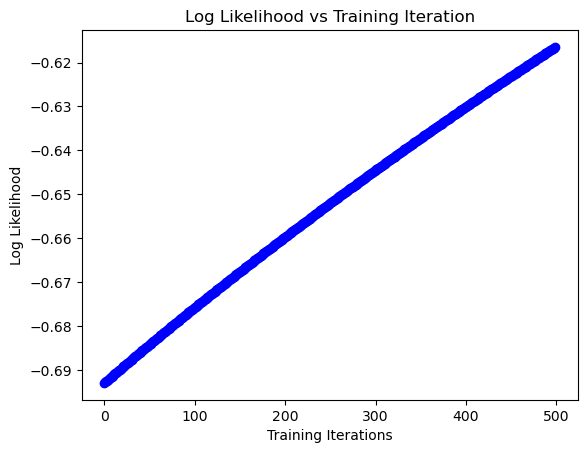

In [427]:
import matplotlib.pyplot as plt

plt.scatter(np.arange(0,len(likelihood_history),1), likelihood_history, color = 'blue') 
plt.title('Log Likelihood vs Training Iteration') 
plt.xlabel('Training Iterations') 
plt.ylabel('Log Likelihood') 
plt.show() 

Predict sentiment of the first two documents

In [428]:
sentiment = predict(X_test_sentiment[:2], sentiment_model_weights, sentiment_model_bias)
sentiment

[1, 1]

In [429]:
print(sentiment_model_weights[:2])
print(sentiment_model_bias)

[0.01444745 0.00479099]
0.16699357784124916


Now that we have fitted the model, we can inspect the weights (coefficients) and bias as follows:

In [430]:
print(products['reviews'][0])

I initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing the paperwhite is great but if you have spending money go for the voyageFortunately I had friends who owned each so I ended up buying the paperwhite on this basis both models now have 300 ppi so the 80 dollar jump turns out pricey the voyages page press isnt always sensitive and if you are fine with a specific setting you dont need auto light adjustmentIts been a week and I am loving my paperwhite no regrets The touch screen is receptive and easy to use and I keep the light at a specific setting regardless of the time of day In any case its not hard to change the setting either as youll only be changing the light level at a certain time of day not every now and then while readingAlso glad that I went for the international shipping option with Amazon Extra expense but delivery was on time with tracking and I didnt need to worry about customs which I may have if I used 

In [431]:
print(products['reviews'][1])

Allow me to preface this with a little history I am was a casual reader who owned a Nook Simple Touch from 2011 Ive read the Harry Potter series Girl with the Dragon Tattoo series 1984 Brave New World and a few other key titles Fair to say my Nook did not get as much use as many others may have gotten from theirsFast forward to today I have had a full week with my new Kindle Paperwhite and I have to admit Im in love Not just with the Kindle but with reading all over again Now let me relate this review love and reading all back to the Kindle The investment of 13900 is in the experience you will receive when you buy a Kindle You are not simply paying for a screen there is an entire experience included in buying from AmazonI have been reading The Hunger Games trilogy and shall be moving onto the Divergent series soon after Here is the thing with the Nook that hindered me for the past 4 years I was never inspired to pick it up get it into my hands and just dive in There was never that feel

There are a total of `6750` coefficients in the model. Recall from the lecture that positive weights $w_j$ correspond to weights that cause positive sentiment, while negative weights correspond to negative sentiment. 

**Discussion Question:** How many weights are >= 0?

In [432]:
num_positive_weights = np.sum(sentiment_model_weights >= 0)
num_negative_weights = np.sum(sentiment_model_weights < 0)

print("Number of positive weights: %s " % num_positive_weights)
print("Number of negative weights: %s " % num_negative_weights)

Number of positive weights: 34 
Number of negative weights: 30 


## Compute accuracy of the classifier

We will now evaluate the accuracy of the trained classifier. Recall that the accuracy is given by

$$
accuracy = \frac{\textnormal{number of correctly classified examples}}{\textnormal{number of total examples}}
$$
  
This can be computed as follows:

* **Step 1:** Use the trained model to compute class predictions 
* **Step 2:** Count the number of data points when the predicted class labels match the ground truth labels (called `true_labels` below).
* **Step 3:** Divide the total number of correct predictions by the total number of data points in the dataset.

**Discussion Question:** Complete the function below to compute the classification accuracy:

In [433]:
def get_classification_accuracy(prediction_labels, true_labels):    
    # Compute the number of correctly classified examples
    num_correct = np.sum(prediction_labels == true_labels)

    # Then compute accuracy by dividing num_correct by total number of examples
    accuracy = num_correct / len(true_labels)
    return accuracy

In [434]:
accuracy = get_classification_accuracy(predict(X_train_sentiment, sentiment_model_weights, sentiment_model_bias), 
                                       np.ravel(y_train))
print(accuracy)

0.9346793349168646


In [435]:
accuracy = get_classification_accuracy(predict(X_test_sentiment, sentiment_model_weights, sentiment_model_bias), 
                                       np.ravel(y_test))
print(accuracy)

0.8862559241706162


## Confusion Matrix

The accuracy, while convenient, does not tell the whole story. For a fuller picture, we turn to the **confusion matrix**. In the case of binary classification, the confusion matrix is a 2-by-2 matrix laying out correct and incorrect predictions made in each label as follows:
```
              +---------------------------------------------+
              |                Predicted label              |
              +----------------------+----------------------+
              |          (-1)        |         (+1)         |
+-------+-----+----------------------+----------------------+
| True  |(-1) | # of true negative  | # of false positive |
| label +-----+----------------------+----------------------+
|       |(+1) | # of false negative | # of true positive  |
+-------+-----+----------------------+----------------------+
```
* True positive: correct prediction that something is positive
* False positive: incorrect prediction that something is positive
* True negative: correct prediction that something is negative
* False negative: incorrect prediction that something is negative

In [436]:
from sklearn.metrics import confusion_matrix

sentiment_predictions = predict(X_test_sentiment, 
                                sentiment_model_weights, 
                                sentiment_model_bias)
cmatrix = confusion_matrix(y_test, sentiment_predictions)
cmatrix

array([[  1,  14],
       [ 10, 186]])

**Discussion Question**: How many predicted values in the **test set** are **false positives**?

In [437]:
true_neg, false_pos, false_neg, true_pos = cmatrix.ravel()
print('There are {} false positives'.format(false_pos))
print('There are {} false negatives'.format(false_neg))
print('There are {} true positives'.format(true_pos))
print('There are {} true negatives'.format(true_neg))

There are 14 false positives
There are 10 false negatives
There are 186 true positives
There are 1 true negatives


## Precision and Recall

Precision refers to the proportion of positive predictions that are actually correct.

$$
Precision = \frac{TP}{TP + FP}
$$

where

* True positive: correct prediction that something is positive
* False positive: incorrect prediction that something is positive

**First**, let us compute the precision of the logistic regression classifier on the **test_data**.

In [438]:
precision = true_pos/(true_pos+false_pos)
print("Precision on test data: %s" % precision)

Precision on test data: 0.93


**Discussion Question**: Out of all reviews in the **test set** that are predicted to be positive, what fraction of them are **false positives**? (Round to the second decimal place e.g. 0.25)

In [439]:
false_pos / (true_pos + false_pos)

np.float64(0.07)

A complementary metric is **recall**, which measures the ratio between the number of true positives and that of (ground-truth) positive reviews. In other words, recall measures the proportion of actual positive cases that the model correctly identifies:

$$
recall = \frac{TP}{TP + FN}
$$

where

* True positive: correct prediction that something is positive
* False positive: incorrect prediction that something is positive
  
Let us compute the recall on the **test_data**.

**Discussion Question**: What fraction of the positive reviews in the **test_set** were correctly predicted as positive by the classifier?

**Discussion Question**: What is the recall value for a classifier that predicts **+1** for all data points in the **test_data**?

In [440]:
recall = true_pos / (true_pos + false_neg)
print("Recall on test data: %s" % recall)

Recall on test data: 0.9489795918367347


# Other Considerations

**Consideration 1:** Normalize Bag-of-Word and TF-IDF features

Sklearn automatically normalizes BoWs and TF-IDF features (default=l2-norm). L2 normalization is calculated as the square root of the sum of the squared vector values. The L2 norm calculates the distance of the vector coordinate from the origin of the vector space.

$$
||x||_2 = \sqrt{ \sum_{i=1}^{N} x^2_{i}} = \sqrt{x^2_{1} + x^2_{2} + \dots + x^2_{N}}
$$

L1 normalization of a vector is also known as the Manhattan distance or Taxicab norm. The notation for L1 norm of a vector x is ‖x‖1. To calculate the norm, you need to take the sum of the absolute vector values. The L1 norm for both the vectors is the same as we consider absolute values while computing it.

$$
||x||_1 = \sum_{i=1}^{N} |x_{i}| = |x_{1}| + |x_{2}| + \dots + |x_{N}|
$$

**Activity:** Compare the accuracy, precision, and recall of L1- and L2-norm and observe the difference in performance.

**Consideration 2:** Distribution of positive and negative examples in the dataset

array([[<Axes: title={'center': 'sentiment'}>]], dtype=object)

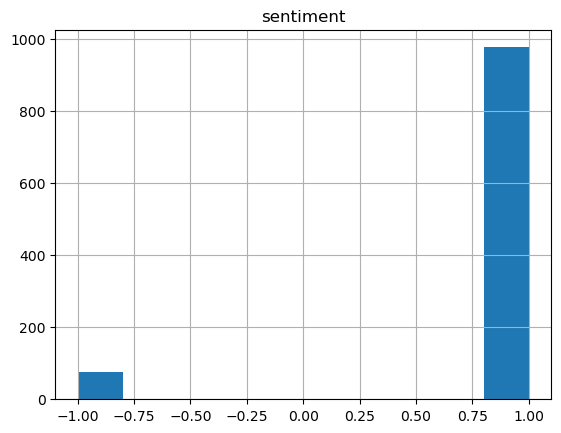

In [441]:
# View number of positive and negative sentiment
products.hist(column=['sentiment'])

Note, there are significantly more positive reviews than negative reviews which can bias model performance. 

**Activity:** Explore using an even number of positive and negative examples and observe model performance.

**Consideration 3:** Consider n-gram models. Use bi-gram and tri-gram models. Observe the change in model performance.